# Evaluación cuantitativa de algoritmos de cambio semánticos

In [1]:
# Importar librería
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import pickle
import os
import re
import random as rn
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap
import matplotlib.pyplot as plt
import itertools

from gensim.models import Word2Vec
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
tqdm.pandas()

In [2]:
# Configurar
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") + '/muerte_subita/' # Acceder a las variables de entorno
modelo_dir =  RESULTADOS_DIR+ '/archivos_out/modelos_swmwosge_808811150/'
pd.set_option('display.max_colwidth', None)

In [3]:
# Umbrales cables
umbral_top = 0 # antes 5 se eliminan las palabras nacional (836), creacion (628), programa (488), regimen	(485), salud (483). 
umbral_frec_menos = 2 # < antes 5 mediana de frecuencia de ocurrencia de palabra en titulos 
umbral_frec_menos_full  = 5 # antes 9 < amedia de ocurrencia de palabra en periodo de 5 años
topn_vecinos = 100

# Config modelo https://radimrehurek.com/gensim/models/word2vec.html
tam_vector = 80 # Dimensionalidad de los vectores de palabras.
ventana = 8 # ventana ( int , opcional ): distancia máxima entre la palabra actual y la palabra prevista dentro de una oración.
min_frec = 8 #  Ignora todas las palabras con una frecuencia total menor que esta.
w = 1  # utilice estos muchos subprocesos de trabajo para entrenar el modelo (=entrenamiento más rápido con máquinas de múltiples núcleos).
s = 1 # Algoritmo de entrenamiento: 1 para skip-gram; de lo contrario, CBOW.
e = 150 # Número de iteraciones (épocas) en el corpus. (Anteriormente: iter )
semilla = 1 # seed ( int , opcional ): Semilla para el generador de números aleatorios. 
iteracion = 50

In [4]:
all_dfs = {}

df_names = [
    'procrustes'
]

basenames = [
    'estabilidad_procrustes'
]

descriptions = [
    'Procrustes ortogonal'
]

flag = [
    True,
    False

]

In [5]:
# Unificamos archivos
for (i, (df_name, basename, description,f)) in enumerate(zip(df_names, basenames, descriptions,flag)):
    filename = modelo_dir+'/'+basename+'/'+basename+'_iter'+str(iteracion)+'_tam'+str(tam_vector)+'.csv'
    print('Leyendo', filename, end='...')
    df = pd.read_csv(filename)
    all_dfs[df_name] = {
        'df': df,
        'descripcion': description,
        'bandera': f
    }
    print('archivos:', df.shape)

Leyendo C:/Users/Usuario/iamas_iniciativasleg_salud/src/data//muerte_subita//archivos_out/modelos_swmwosge_808811150//estabilidad_procrustes/estabilidad_procrustes_iter50_tam80.csv...archivos: (1350, 7)


In [6]:
# Normalizar nombres
all_dfs['procrustes']['df'].rename(
    columns={
        'top10_vecindad_t1': 'neighbors_t1', 
        'top10_vecindad_t2':'neighbors_t2'},
    inplace=True)
all_dfs['procrustes']['df'].head(1)

,iteracion,par_periodo,palabra,similaridad_semantica,cantidad_palabras_comun,neighbors_t1,neighbors_t2
0,16,"(2009, 2014)",proyecto,0.69031,17,"[('salud', 0.9823289513587952), ('persona', 0.9607980251312256), ('paro', 0.9006549119949341), ('lugar', 0.9005680680274963), ('centro', 0.9005435109138489), ('privado', 0.8947027921676636), ('dea', 0.872826874256134), ('evento', 0.8461856245994568), ('cardiaco', 0.8322585225105286), ('caso', 0.8233528733253479)]","[('articulo', 0.9491197466850281), ('deber', 0.7432569265365601), ('forma', 0.7293074727058411), ('salud', 0.6228327751159668), ('tratamiento', 0.6161350011825562), ('centro', 0.6078642010688782), ('publico', 0.5712985992431641), ('ley', 0.5621874928474426), ('causa', 0.5522525310516357), ('automatico', 0.5341042876243591)]"


In [7]:
#print(all_dfs['NN']['df']['par_periodo'].unique())

Aplicamos la comparación a la tarea de detección de cambios en el uso de palabras primero para los pareas 2009-2013 y 2014-2018 y luego, para 2014-2018 y 2019-2023. 
Utilizamos la intersección @k, propuesta por Gonen et al., que mide el porcentaje de palabras compartidas en las k palabras más cambiadas durante varios reinicios, cambiando cada vez la semilla aleatoria.

 Para cada enfoque (p. ej., procrustes) y entre los dos períodos, medimos el cambio en el uso de palabras y detectamos las palabras más cambiadas. Al repetir la medición con diferentes semillas aleatorias (50 iteraciones), calculamos las palabras comunes cambiadas en las repeticiones. Específicamente, ejecutamos cada enfoque de cambio de uso y recopilamos las k palabras más cambiadas, donde k ∈ k = [10, 25, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600,650,700,750,800,850,900,950,1000]
. Luego, para cada uno de los (50 2 )= Combinaciones de 50 elementos tomados de 2 en 2 = 1225  pares de ejecuciones diferentes y para cada uno de los valores de k, medimos el porcentaje de palabras compartidas en las predicciones de palabras con mayor cambio de cada enfoque. Un valor de cero entre un par de ejecuciones significa que no hay palabras compartidas en sus predicciones, lo que indica alta variabilidad, mientras que un valor de uno indica alta estabilidad.

In [8]:
iteracion

50

In [9]:
k = [10, 25, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600,650,700,750,800,850,900,950,1000]
all_pairs = list(itertools.combinations(range(iteracion), 2))
print(len(k))
print(all_pairs)

23
[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17), (0, 18), (0, 19), (0, 20), (0, 21), (0, 22), (0, 23), (0, 24), (0, 25), (0, 26), (0, 27), (0, 28), (0, 29), (0, 30), (0, 31), (0, 32), (0, 33), (0, 34), (0, 35), (0, 36), (0, 37), (0, 38), (0, 39), (0, 40), (0, 41), (0, 42), (0, 43), (0, 44), (0, 45), (0, 46), (0, 47), (0, 48), (0, 49), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (1, 19), (1, 20), (1, 21), (1, 22), (1, 23), (1, 24), (1, 25), (1, 26), (1, 27), (1, 28), (1, 29), (1, 30), (1, 31), (1, 32), (1, 33), (1, 34), (1, 35), (1, 36), (1, 37), (1, 38), (1, 39), (1, 40), (1, 41), (1, 42), (1, 43), (1, 44), (1, 45), (1, 46), (1, 47), (1, 48), (1, 49), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12), (2, 13), (2, 14), (2, 15), (2, 16), (2, 17), (2, 18), (2,

In [10]:
# n! / (r! * (n - r)!) 
print(len(all_pairs))


1225


In [11]:
estabilidad_k = {}
for par_periodo in ['(2009, 2014)','(2014, 2019)']: 
    estabilidad_k[par_periodo]= {}
    print(par_periodo)
    for method_name, method_results in all_dfs.items(): 
        print(method_name)
        label = method_results['descripcion']
        
        df = method_results['df']
        df = df[df['par_periodo']== par_periodo]
                
        flag = method_results['bandera']
        
        X = []
        Y = []
        
        yerr = [
        [], # lower errors
        [] # upper errors
        ]
        for n in k:
            intersection_per_pair = np.zeros(len(all_pairs))

            for i, pair in enumerate(all_pairs):

                iteration_0_topk = df.loc[(df.iteracion==pair[0])].sort_values('similaridad_semantica', ascending=flag)['palabra'][:n]
                iteration_1_topk = df.loc[(df.iteracion==pair[1])].sort_values('similaridad_semantica', ascending=flag)['palabra'][:n]
                intersection = len(set(iteration_0_topk).intersection(set(iteration_1_topk)))
                intersection_per_pair[i] = intersection / n #jaccard

            intersection_at_k = np.mean(intersection_per_pair)
            Y.append(intersection_at_k)
            X.append(n)
            res = bootstrap((intersection_per_pair,), np.mean, confidence_level=0.95)
            yerr[0].append(intersection_at_k - res.confidence_interval.low)
            yerr[1].append(res.confidence_interval.high - intersection_at_k)

        dic = {'k':X, 'promedio interseccion k ': Y, 'errores inferiores': yerr[0], 'errores superiores': yerr[1]}
        estabilidad_k[par_periodo][label] = dic


(2009, 2014)
procrustes


C:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\scipy\stats\_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_2904\2059284926.py:34: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  res = bootstrap((intersection_per_pair,), np.mean, confidence_level=0.95)


(2014, 2019)
procrustes


* Intersección @k: mide el porcentaje de palabras compartidas en las predicciones de k palabras con mayor cambio por par de ejecuciones.

    * Valor cercano a 1.0 : alta estabilidad, resultados consistentes.
    * Valor cercano a 0.0 : alta variabilidad, resultados sensibles a la semilla.

In [12]:
#estab_df = pd.DataFrame.from_dict(estabilidad_k, orient="columns")
#display(estab_df)

filas = []

for periodo, metodos in estabilidad_k.items():
    for metodo, datos in metodos.items():
        for i in range(0,len(datos['k'])):
            filas.append({
                'periodo': periodo,
                'metodo': metodo,
                'k': datos['k'][i],
                'promedio interseccion k': datos['promedio interseccion k '][i],
                'errores inferiores': datos['errores inferiores'][i],
                'errores superiores': datos['errores superiores'][i]
            })

# Crear DataFrame
estab_df = pd.DataFrame(filas)
estab_df.to_csv(modelo_dir+'/promedio_interseccion_k.csv',index=False)
estab_df.describe()

,k,promedio interseccion k,errores inferiores,errores superiores
count,46.000000,46.000000,24.000000,24.000000
mean,461.304348,0.114385,0.000150,0.000160
std,318.811046,0.216569,0.000733,0.000783
min,10.000000,0.010000,0.000000,0.000000
25%,162.500000,0.018359,0.000000,0.000000
50%,450.000000,0.029740,0.000000,0.000000
75%,737.500000,0.080750,0.000000,0.000000
max,1000.000000,1.000000,0.003592,0.003837


C:\Users\Usuario\AppData\Local\Temp\ipykernel_2904\1971568066.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels)) # Elegimos un mapa de colores y obtenemos los colores necesarios


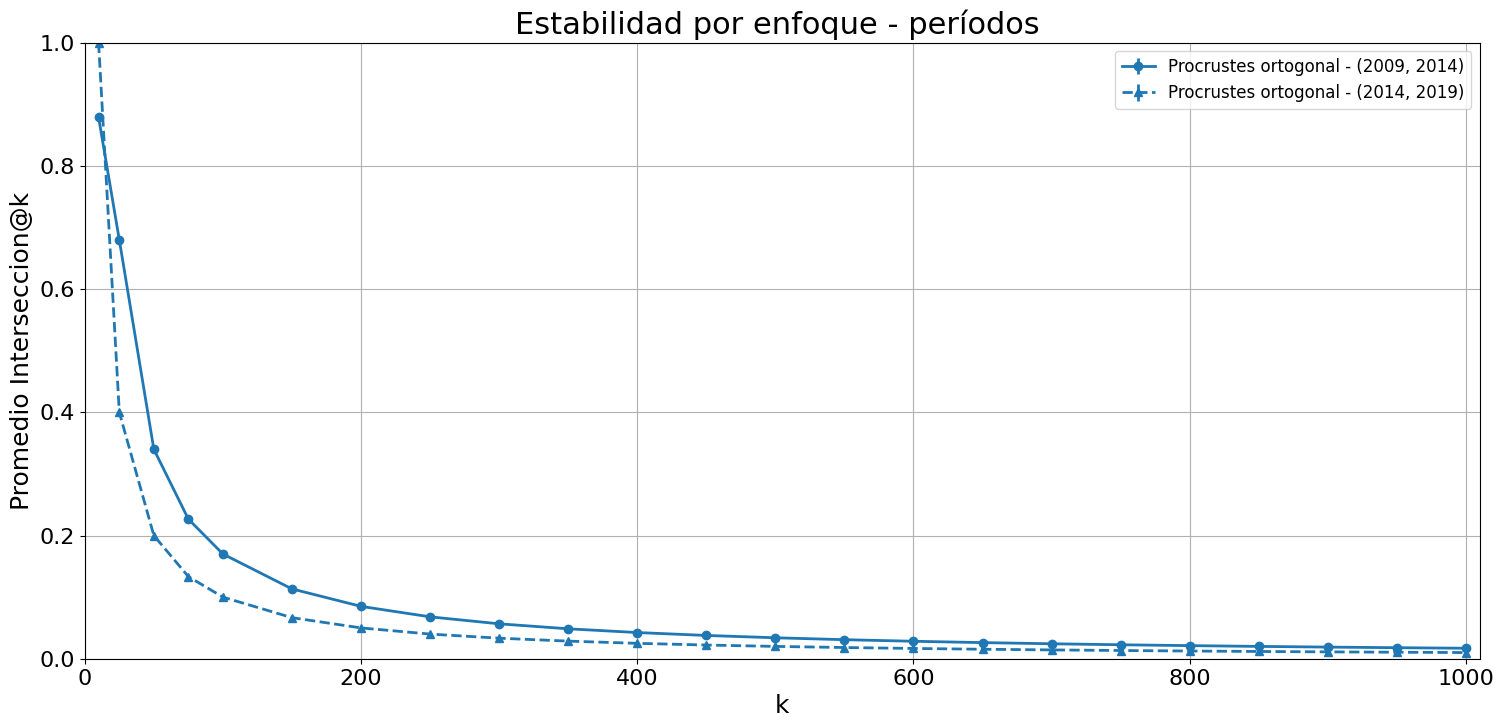

In [13]:
fig = plt.figure(figsize=(18, 8))
line_styles = {'(2009, 2014)': '-o', '(2014, 2019)': '--^'}
unique_labels = sorted(list(set(k for periodo_data in estabilidad_k.values() for k in periodo_data.keys())))
colors = plt.cm.get_cmap('tab10', len(unique_labels)) # Elegimos un mapa de colores y obtenemos los colores necesarios
color_map = {label: colors(i) for i, label in enumerate(unique_labels)}

for i, label in enumerate(unique_labels):
    for par_periodo, dic in estabilidad_k.items():
        if label in dic:
            datos = dic[label]
            X = datos['k']
            Y = datos['promedio interseccion k ']
            yerr = [datos['errores inferiores'], datos['errores superiores']]
            plt.errorbar(X, Y, yerr=yerr, label=f'{label} - {par_periodo}', linewidth=2, fmt=line_styles[par_periodo], color=color_map[label])

plt.gca().tick_params(axis='both', which='major', labelsize=16)
plt.ylim(0, 1)
plt.xlim(0, 1010)
plt.xlabel('k', fontsize=18)
plt.ylabel('Promedio Ιnterseccion@k', fontsize=18)
plt.title('Estabilidad por enfoque - períodos ', fontsize=22)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()


In [14]:
print("Promedio por periodo")
estab_df.groupby(['periodo'])['promedio interseccion k'].mean().reset_index().sort_values(['promedio interseccion k'], ascending=False)


Promedio por periodo


,periodo,promedio interseccion k
0,"(2009, 2014)",0.130819
1,"(2014, 2019)",0.097951


In [15]:
print("Promedio por periodo")
estab_df.groupby(['metodo'])['promedio interseccion k'].mean().reset_index().sort_values(['promedio interseccion k'], ascending=False)


Promedio por periodo


,metodo,promedio interseccion k
0,Procrustes ortogonal,0.114385


In [16]:
print("Promedio por periodo y método")
estab_df.groupby(['periodo', 'metodo'])['promedio interseccion k'].mean().reset_index().sort_values(['promedio interseccion k'], ascending=False)


Promedio por periodo y método


,periodo,metodo,promedio interseccion k
0,"(2009, 2014)",Procrustes ortogonal,0.130819
1,"(2014, 2019)",Procrustes ortogonal,0.097951


In [17]:
estab_df.sort_values(by='promedio interseccion k', ascending=False)

,periodo,metodo,k,promedio interseccion k,errores inferiores,errores superiores
23,"(2014, 2019)",Procrustes ortogonal,10,1.000000,NaN,NaN
0,"(2009, 2014)",Procrustes ortogonal,10,0.878939,0.003592,0.003837
1,"(2009, 2014)",Procrustes ortogonal,25,0.680000,0.000000,0.000000
24,"(2014, 2019)",Procrustes ortogonal,25,0.400000,0.000000,0.000000
2,"(2009, 2014)",Procrustes ortogonal,50,0.340000,0.000000,0.000000
3,"(2009, 2014)",Procrustes ortogonal,75,0.226667,NaN,NaN
25,"(2014, 2019)",Procrustes ortogonal,50,0.200000,0.000000,0.000000
4,"(2009, 2014)",Procrustes ortogonal,100,0.170000,0.000000,0.000000
26,"(2014, 2019)",Procrustes ortogonal,75,0.133333,NaN,NaN
5,"(2009, 2014)",Procrustes ortogonal,150,0.113333,NaN,NaN



La figura y las tablas de resultados muestran la intersección promedio @k entre los 1225 pares de ejecuciones diferentes para cada enfoque y periodo, con intervalos de confianza del 95 % calculados mediante el método bootstrap. 

Se observa que el método Procrustes ortogonal presenta muy baja estabilidad general, especialmente para k >= 50. 

 * La intersección promedio de procruste es 0.11, un valor bajo de de solapamiento entre las k palabras más cambiadas identificadas por múltiples ejecuciones del modelo con diferentes inicializaciones aleatorias. 
 * La media de intersección es de 0.13 para 2009–2014 y 0.10 para 2014–2019.

Se tomará **k= 25** para evaluar cualitativamente los enfoques y los períodos, al ser el valor de intesección entre los enfoques y tener un 60% de palabras compartidas en las predicciones de palabras con mayor cambio de cada enfoque.


### Palabras más cambiadas por período de 5 años

In [18]:
#print(all_dfs['NN']['df']['par_periodo'].unique())
#print(all_dfs['procrustes']['df']['par_periodo'].unique())
pares_periodo = [ (2009, 2014),(2014, 2019)]
pares_periodo

[(2009, 2014), (2014, 2019)]

In [19]:
''' para verificar
# Frecuencia de palabras por período
df = all_dfs['NN']['df']
par_periodo = (2009, 2014)
df = df[df['par_periodo'] == str(par_periodo)]
flag = all_dfs['NN']['bandera']
frecPer1 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[0])+'.csv')
frecPer2 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[1])+'.csv')
frecPer1.columns = ['palabra', 'frec1', 'porc1']
frecPer2.columns = ['palabra', 'frec2', 'porc2']
df = df[df['par_periodo'] == str(par_periodo)]
df.head(2)
'''

" para verificar\n# Frecuencia de palabras por período\ndf = all_dfs['NN']['df']\npar_periodo = (2009, 2014)\ndf = df[df['par_periodo'] == str(par_periodo)]\nflag = all_dfs['NN']['bandera']\nfrecPer1 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[0])+'.csv')\nfrecPer2 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[1])+'.csv')\nfrecPer1.columns = ['palabra', 'frec1', 'porc1']\nfrecPer2.columns = ['palabra', 'frec2', 'porc2']\ndf = df[df['par_periodo'] == str(par_periodo)]\ndf.head(2)\n"

### Evaluación cualitativa: Palabras con mayor cambio entre pares [2009-2014) y [2014-2019) y [2014-2019) a  [2019-2024)

Evaluamos cualitativamente las 300 palabras con mayor cambio entre los pares de períodos, según cada enfoque. Introducimos un umbral de frecuencia de 5 ocurrencias en al menos uno de los períodos de 5 años para los enfoques que aún no cuentan con umbrales de frecuencia.

* Frecuencia media de las palabras en cada periodo es 5

ojo: El 75% del total de palabras en los tres periodos presentan una frecuencia inferior a frecuencia = 4.



In [20]:
n = 25
at_least_in_any_decade = 5

csvs = []
topn_periodo_dic = {}
for par_periodo in  [(2009, 2014),(2014, 2019)]:
    
    enfoque_topn = {} 
    for method_name, method_results in all_dfs.items(): 

        print(method_name)
        label = method_results['descripcion']
        df = method_results['df']
        df = df[df['par_periodo']== str(par_periodo)]
        flag = method_results['bandera']

        frecPer1 = pd.read_csv(RESULTADOS_DIR+'archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[0])+'.csv')
        frecPer2 = pd.read_csv(RESULTADOS_DIR+'archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[1])+'.csv')
        frecPer1 = frecPer1[['Palabra',	'Frecuencia','Porcentaje']]
        frecPer2 = frecPer2[['Palabra',	'Frecuencia','Porcentaje']]
        frecPer1.columns = ['palabra', 'frec1', 'porc1']
        frecPer2.columns = ['palabra', 'frec2', 'porc2']
        print(frecPer1.shape)
        print(frecPer2.shape)
        print(frecPer1)
    
        df_topn = df.loc[(df.iteracion==0)]
        #controlar frec
        df_topn = df_topn.merge(frecPer1, how='left', on='palabra')
        df_topn = df_topn.merge(frecPer2, how='left', on='palabra')

        
        df_topn['max_freq_of_any_decade'] = df_topn[['frec1', 'frec2']].max(axis=1)
        df_topn.drop(['frec1', 'frec2', 'porc1', 'porc2'], axis=1, inplace=True) 
        df_topn = df_topn.loc[df_topn.max_freq_of_any_decade>= at_least_in_any_decade].head(n)
        df_topn = df_topn[['palabra','similaridad_semantica','neighbors_t1', 'neighbors_t2']].sort_values('similaridad_semantica', ascending=flag).head(n)
        enfoque_topn[method_name] = df_topn
        
        new_name = method_name.lower().replace(' ', '_')
        new_name = new_name.replace('-', '')
        new_periodo = str(par_periodo)
        new_periodo = new_periodo.replace('(', '')
        new_periodo = new_periodo.replace(')', '')
        new_periodo = new_periodo.replace(',', '_')
        
        csv_path = modelo_dir+'/'+new_name+'_periodo'+str(new_periodo)+'_top'+str(n)+'.csv'
        #csvs.append(csv_path)

        df_topn.to_csv(csv_path, index=False)
        csvs.append(df_topn)

    topn_periodo_dic[par_periodo] = enfoque_topn

procrustes
(801, 3)
(686, 3)
          palabra  frec1     porc1
0        eventual      1  0.000583
1           crear      1  0.000583
2      especifico      1  0.000583
3    coordinacion      1  0.000583
4    problematica      1  0.000583
..            ...    ...       ...
796       publico     22  0.012828
797         lugar     23  0.013411
798       persona     26  0.015160
799           dea     26  0.015160
800      articulo     26  0.015160

[801 rows x 3 columns]
procrustes
(686, 3)
(694, 3)
         palabra  frec1     porc1
0        prestir      1  0.000541
1        tecnica      1  0.000541
2    incidenciar      1  0.000541
3    identificar      1  0.000541
4       elemento      1  0.000541
..           ...    ...       ...
681    actividad     18  0.009730
682     cardiaco     19  0.010270
683    deportivo     19  0.010270
684     programa     22  0.011892
685     articulo     27  0.014595

[686 rows x 3 columns]


In [21]:
from matplotlib_venn import venn2

K= 10
seman_dic = {}
for periodo, dicTop in topn_periodo_dic.items():
    print(periodo)
    seman_dic['Procrustes_'+str(periodo[0])+'_'+str(periodo[0])] = set(pal[0] for pal in dicTop['procrustes'][['palabra']].head(K).values)
    
    #display(dicTop['procrustes'].head(K))
    print("Procrustes: ",seman_dic['Procrustes_'+str(periodo[0])+'_'+str(periodo[0])])
    

(2009, 2014)
Procrustes:  {'deber', 'persona', 'ley', 'tratamiento', 'proyecto', 'centro', 'cardiaco', 'muerte', 'publico', 'caso'}
(2014, 2019)
Procrustes:  {'deber', 'causa', 'persona', 'ley', 'proyecto', 'cardiaco', 'publico', 'caso', 'articulo', 'salud'}


* Período: (2009, 2014)
    * Procrustes detecta términos institucionales, jurídicos y administrativos (legal, declaración, inciso, materia, ingreso). 'acompañante' aparece en ambos métodos
    * NN capta conceptos de salud pública (dengue, patología, atención, psicológico).
* Período: (2014, 2019)
    * Ambos métodos coinciden en varias palabras clave: comunitario, gratuidad, domiciliario, adecuado lo que refuerza su confiabilidad y relevancia. 
